In [33]:
# Import the packages needed for the examples included in this notebook
import numpy as np
import matplotlib.pyplot as plt
import control as ct

In [34]:
numc = 100
denc = [1, 3, 2]
sysc = ct.tf(numc,denc)
print(sysc)

<TransferFunction>: sys[28]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       100
  -------------
  s^2 + 3 s + 2


In [35]:
T = 0.1
#sysd = ct.tf(numc, denc, T, 'zoh')
sysd = ct.sample_system(sysc, T, method='zoh')
print(sysd)


<TransferFunction>: sys[28]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

    0.4528 z + 0.4097
  ----------------------
  z^2 - 1.724 z + 0.7408


Definimos el controlador

In [36]:
numcont =  [1.0490, 0.9492]
dencont = [1.0000, -0.5250, -0.4750 ]
syscont = ct.tf(numcont, dencont, T)
print(syscont)

<TransferFunction>: sys[30]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

    1.049 z + 0.9492
  ---------------------
  z^2 - 0.525 z - 0.475


In [37]:
sal_loop = ct.feedback(sysd, syscont, sign = -1)
print(sal_loop)
sal_loop1 = ct.series(sysd, syscont)
print(sal_loop1)

<TransferFunction>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.4528 z^3 + 0.172 z^2 - 0.4302 z - 0.1946
  ---------------------------------------------
  z^4 - 2.249 z^3 + 1.646 z^2 + 1.289 z + 0.037
<TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

           0.475 z^2 + 0.8596 z + 0.3889
  -----------------------------------------------
  z^4 - 2.249 z^3 + 1.171 z^2 + 0.4298 z - 0.3519


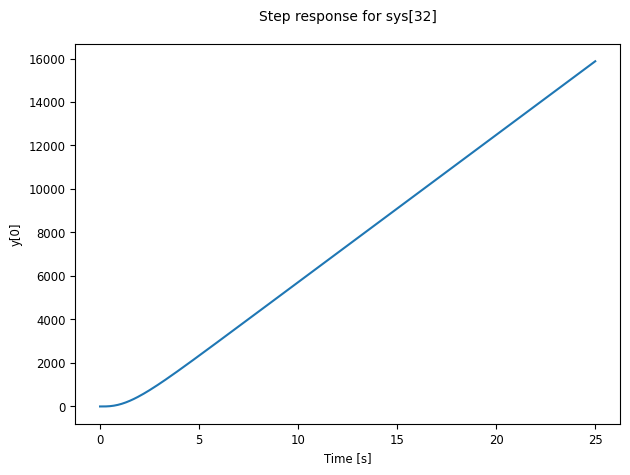

In [38]:
sal_loop_r = ct.step_response(sal_loop1).plot()